In [43]:
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn

from graph_builder import assemble_graph
from models.outfit_gnn import OutfitGNNModel
from train import train_loop

from features.image_features import ImageEncoder, extract_image_feature, IMAGE_EMBED_DIM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGES_ROOT = Path("../sample_data/images")

In [44]:
def predict_compatibility_from_images(img1_path, img2_path, gnn_model):
    import torch
    from pathlib import Path
    from features.image_features import ImageEncoder, extract_image_feature

    device = torch.device("cpu")

    # 1. Image Encoder on CPU
    image_model = ImageEncoder().to(device)
    gnn_model = gnn_model.to(device)
    gnn_model.eval()

    # 2. Extract 512D image embeddings
    feat1 = extract_image_feature(Path(img1_path), image_model, device=device)
    feat2 = extract_image_feature(Path(img2_path), image_model, device=device)

    feat1 = torch.tensor(feat1, dtype=torch.float32).unsqueeze(0)   # (1,512)
    feat2 = torch.tensor(feat2, dtype=torch.float32).unsqueeze(0)   # (1,512)

    # 3. Create dummy graph: 1 node, no edges
    edge_index = torch.zeros((2,0), dtype=torch.long)

    # 4. Pass THROUGH the full GNN encoder (conv layers + project)
    with torch.no_grad():
        z1 = gnn_model.encoder(feat1, edge_index)   # (1,128)
        z2 = gnn_model.encoder(feat2, edge_index)   # (1,128)

        score = gnn_model.scorer(z1, z2)
    return float(score.item())

In [45]:
def show_and_predict(img1_path, img2_path, gnn_model):
    import matplotlib.pyplot as plt
    from PIL import Image

    # --- Load images ---
    img1 = Image.open(img1_path).convert("RGB")
    img2 = Image.open(img2_path).convert("RGB")

    # --- Display them side by side ---
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Image 1")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("Image 2")
    plt.axis("off")

    plt.show()

    # --- Make compatibility prediction ---
    score = predict_compatibility_from_images(img1_path, img2_path, gnn_model)

    print("\nFinal Compatibility Score:", score)
    return score


In [78]:
model1 = OutfitGNNModel(
    in_dim=512,
    hidden_dims=[256,256],
    out_dim=128
).to(device)

model1.load_state_dict(torch.load('./weights/model_epoch_100.pt', map_location='cpu'))

<All keys matched successfully>

# Best matching shoes on the top

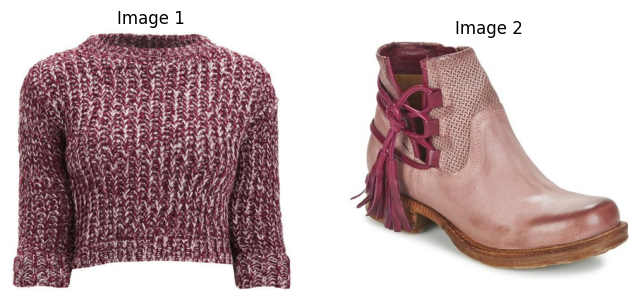


Final Compatibility Score: -0.29181766510009766


In [80]:
_ = show_and_predict(
    f"{IMAGES_ROOT}/209432387/1.jpg",
    f"{IMAGES_ROOT}/209432387/6.jpg",
    model1
)

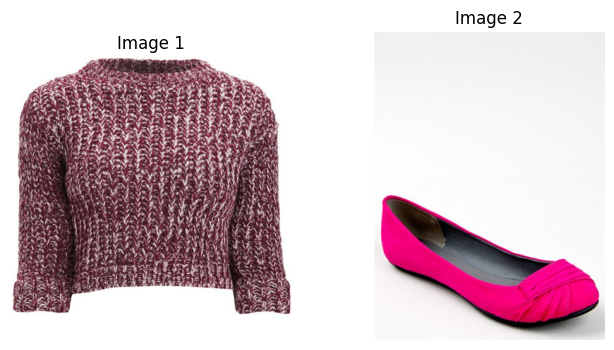


Final Compatibility Score: -1.5961188077926636


In [79]:
_ = show_and_predict(
    f"{IMAGES_ROOT}/209432387/1.jpg",
    f"{IMAGES_ROOT}/125301887/3.jpg",
    model1
)

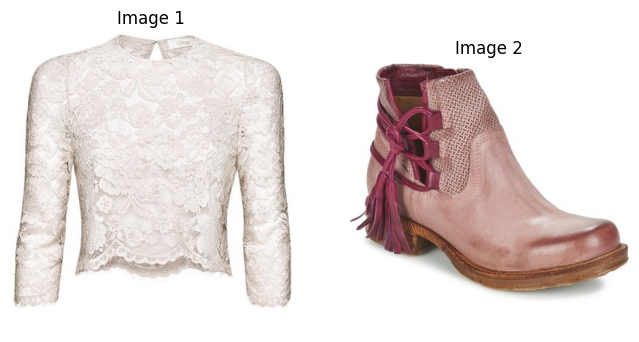


Final Compatibility Score: -1.2839126586914062


In [82]:
_ = show_and_predict(
    f"{IMAGES_ROOT}/125301887/1.jpg",
    f"{IMAGES_ROOT}/209432387/6.jpg",
    model1
)

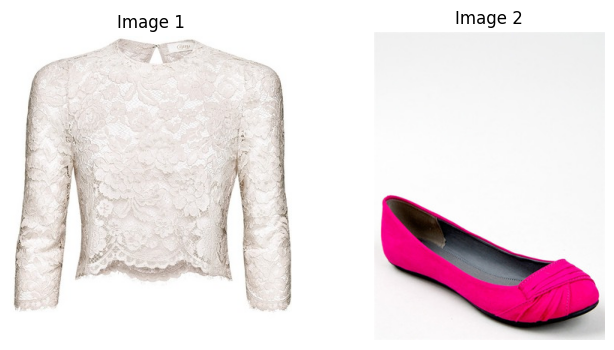


Final Compatibility Score: -0.8364213109016418


In [81]:
_ = show_and_predict(
    f"{IMAGES_ROOT}/125301887/1.jpg",
    f"{IMAGES_ROOT}/125301887/3.jpg",
    model1
)